,Gemeente,PercentageLinkseStemmen
0,Eemsdelta,26.53
1,Groningen,53.35
2,Het Hogeland,29.45
3,Midden-Groningen,26.67
4,Oldambt,24.00


Aantal gemeenten: 342
Gemeenten met stemgegevens: 342
Gemeenten zonder stemgegevens: 0


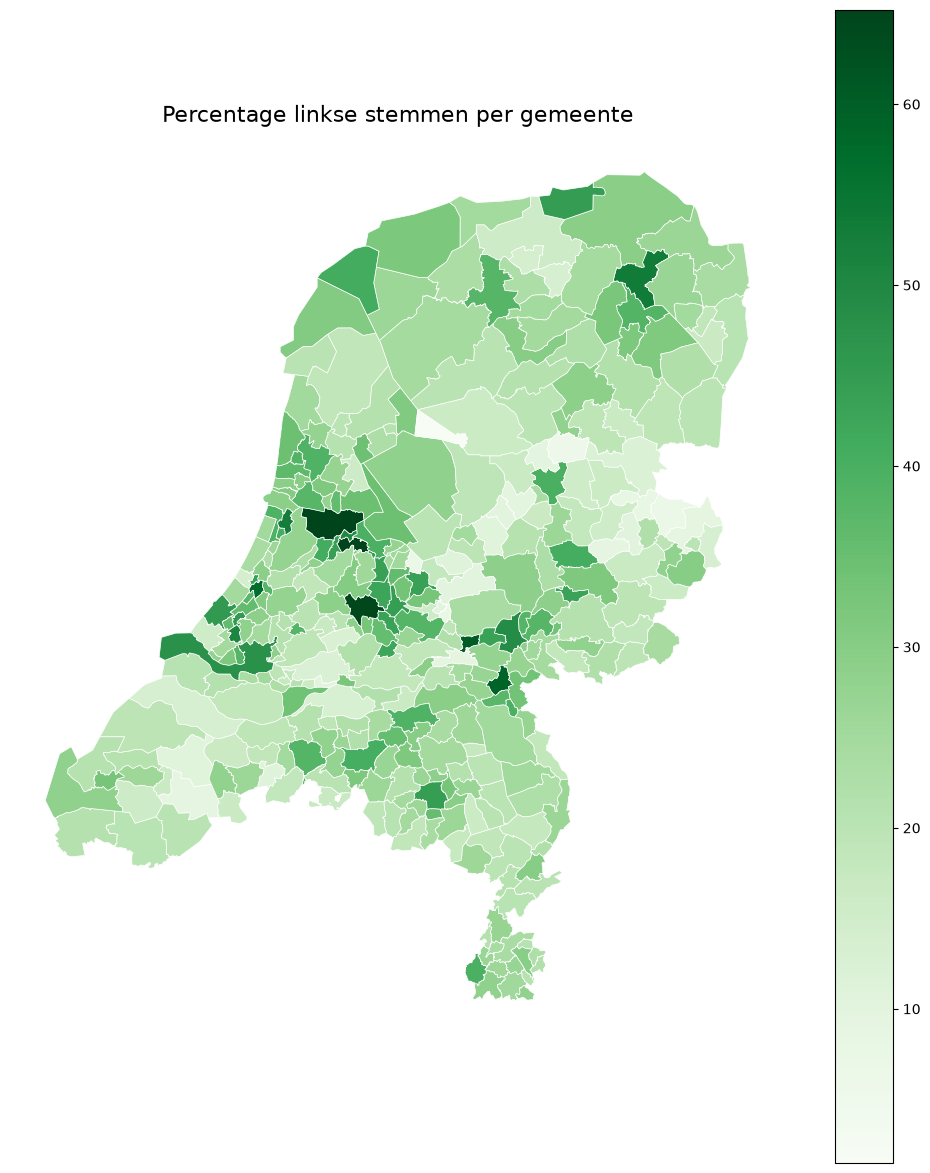

In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


# ============================================================
# 1. DATA MET LINKSE STEMMEN INLEZEN
# ============================================================

stemmen = pd.read_csv(
    "/Users/mirtebatema/Desktop/TIL_2026/programming/opdracht/linkse_stemmen_per_gemeente.csv",
    sep=None,
    engine="python"
)

# Alleen de kolommen die we nodig hebben
links = stemmen[
    ["Gemeente", "PercentageLinkseStemmen"]
].copy()

# Ontbrekende waarden verwijderen
links = links.dropna(
    subset=["Gemeente", "PercentageLinkseStemmen"]
)

# Gemeentenamen opschonen
links["Gemeente"] = links["Gemeente"].str.strip()

display(links.head())


# ============================================================
# 2. GEMEENTEGRENZEN VAN NEDERLAND OPHALEN
# ============================================================

gemeente_url = (
    "https://api.pdok.nl/kadaster/brk-bestuurlijke-gebieden/"
    "ogc/v1/collections/gemeentegebied/items?f=json&limit=500"
)

gemeenten = gpd.read_file(gemeente_url)

# Gemeentenamen opschonen
gemeenten["naam"] = gemeenten["naam"].str.strip()

print("Aantal gemeenten:", len(gemeenten))


# ============================================================
# 3. STEMDATA AAN GEMEENTEN KOPPELEN
# ============================================================

kaart_links = gemeenten.merge(
    links,
    left_on="naam",
    right_on="Gemeente",
    how="left"
)

print(
    "Gemeenten met stemgegevens:",
    kaart_links["PercentageLinkseStemmen"].notna().sum()
)

print(
    "Gemeenten zonder stemgegevens:",
    kaart_links["PercentageLinkseStemmen"].isna().sum()
)


# ============================================================
# 4. KAART MAKEN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 12))

kaart_links.plot(
    column="PercentageLinkseStemmen",
    cmap="Greens",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "Geen data"
    }
)


# ============================================================
# 5. TITEL EN OPMAAK
# ============================================================

ax.set_title(
    "Percentage linkse stemmen per gemeente",
    fontsize=16
)

ax.axis("off")

plt.tight_layout()
plt.show()